🚀 Step 1: Load & Clean the Dataset
In this step, we will:
✅ Load the dataset (Fresh start)
✅ Remove duplicate rows (Ensuring data quality)
✅ Fix column names (Remove unnecessary spaces)

📌 Step 1 Code: Load & Clean the Data

In [1]:
# Step 1: Load & Clean the Dataset 🚀

# Import necessary libraries
import pandas as pd
import numpy as np

# Load the dataset (Fresh Start)
file_path = r"C:\Users\alire\OneDrive\Desktop\ALIREZA\Thesis\Data\1\Thesis.xlsx"
df = pd.read_excel(file_path)

# Remove spaces from column names
df.columns = df.columns.str.strip()

# Remove duplicate rows (Ensuring data quality)
df = df.drop_duplicates()

# Display dataset info after cleaning
print("\n✅ Cleaned Dataset Info:")
df.info()

# Show first 5 rows after cleaning
print("\n🔹 First 5 Rows After Cleaning:")
display(df.head())



✅ Cleaned Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 176 entries, 0 to 176
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   Marque Origin                 176 non-null    object
 1   Calendar Year Production      176 non-null    int64 
 2   N.door                        176 non-null    int64 
 3   Body Style                    176 non-null    object
 4   Drivetrain                    176 non-null    object
 5   Wheelbase(mm)                 176 non-null    int64 
 6   Length(mm)                    176 non-null    int64 
 7   Height(mm)                    176 non-null    int64 
 8   Width(mm)                     176 non-null    int64 
 9   wheels(inch)                  176 non-null    int64 
 10  No. EM                        176 non-null    int64 
 11  Performance of EM(hp)         176 non-null    int64 
 12  Distance Range(km)            176 non-null    int64 
 13  

,Marque Origin,Calendar Year Production,N.door,Body Style,Drivetrain,Wheelbase(mm),Length(mm),Height(mm),Width(mm),wheels(inch),...,Battery Capacity(KWh),Battery Size(L),Battery Mass(kg),Re-Charging Time(min),Top Speed(Km/h),Cruising speed(Km/h),Passenger / Seating Capacity,Level of autonomous,Developement Time,Price(Euro)
0,Europe,2023,5,SUV,RWD,2765,4588,1632,1865,19,...,77,430,450,30,180,120,5,2,5,55000
1,Europe,2025,5,SUV,AWD,2928,4910,1660,1935,20,...,100,500,800,30,200,120,5,2,4,90000
2,Europe,2021,5,SUV,AWD,2764,4588,1632,1865,19,...,64,520,525,35,180,120,5,2,5,41000
3,Europe,2020,4,Sedan,AWD,2900,4990,1410,1960,19,...,85,450,650,22,245,130,4,2,6,99000
4,China,2017,3,Hatchback,RWD,1885,2700,1590,1650,12,...,17,200,135,75,100,80,4,1,2,11500


🔹 Step 2: Data Preprocessing & Encoding 

Now, we will:
✅ Identify categorical columns that need conversion into numerical values.
✅ Apply Label Encoding & One-Hot Encoding (based on the sample notebooks).
✅ Check the transformed dataset to confirm encoding is done correctly.

📌 Why Encoding is Necessary?
Machine learning models only understand numbers 🚀
Columns like "Marque Origin", "Body Style", "Drivetrain", "Battery Type" are text-based.
We must convert them into numerical values for our Linear Regression model.

📌 Step 2 Code: Apply Encoding

In [2]:
# Step 2: Encoding Categorical Data 🔢

from sklearn.preprocessing import LabelEncoder

# List of categorical columns to encode
categorical_columns = ["Marque Origin", "Body Style", "Drivetrain", "Battery Type"]

# Apply Label Encoding
label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])  # Convert text categories into numbers
    label_encoders[col] = le  # Save encoders for later use

# Show first 5 rows after encoding
print("\n✅ First 5 Rows After Encoding:")
display(df.head())

# Check if encoding was successful
print("\n🔹 Unique Encoded Values:")
for col in categorical_columns:
    print(f"{col}: {df[col].unique()}")



✅ First 5 Rows After Encoding:


,Marque Origin,Calendar Year Production,N.door,Body Style,Drivetrain,Wheelbase(mm),Length(mm),Height(mm),Width(mm),wheels(inch),...,Battery Capacity(KWh),Battery Size(L),Battery Mass(kg),Re-Charging Time(min),Top Speed(Km/h),Cruising speed(Km/h),Passenger / Seating Capacity,Level of autonomous,Developement Time,Price(Euro)
0,1,2023,5,1,2,2765,4588,1632,1865,19,...,77,430,450,30,180,120,5,2,5,55000
1,1,2025,5,1,0,2928,4910,1660,1935,20,...,100,500,800,30,200,120,5,2,4,90000
2,1,2021,5,1,0,2764,4588,1632,1865,19,...,64,520,525,35,180,120,5,2,5,41000
3,1,2020,4,2,0,2900,4990,1410,1960,19,...,85,450,650,22,245,130,4,2,6,99000
4,0,2017,3,0,2,1885,2700,1590,1650,12,...,17,200,135,75,100,80,4,1,2,11500



🔹 Unique Encoded Values:
Marque Origin: [1 0 3 2]
Body Style: [1 2 0]
Drivetrain: [2 0 1]
Battery Type: [2 3 0 1]


🔍 What Happened in Step 2?

We converted categorical (text-based) columns into numerical values so that our Linear Regression model can process them.

🔹 Encoding Results
Marque Origin → {1, 0, 3, 2}
Body Style → {1, 2, 0}
Drivetrain → {2, 0, 1}
Battery Type → {2, 3, 0, 1}
Now, instead of words like "Europe" or "SUV", the model sees numbers (0,1,2,3), which is crucial for machine learning.

📊 Visualization: Distribution of Categorical Data (Before & After Encoding)

To better understand our encoded features, let’s create bar plots to show the count of each category.

📌 Step 2.1 Code: Plot Distribution of Encoded Features

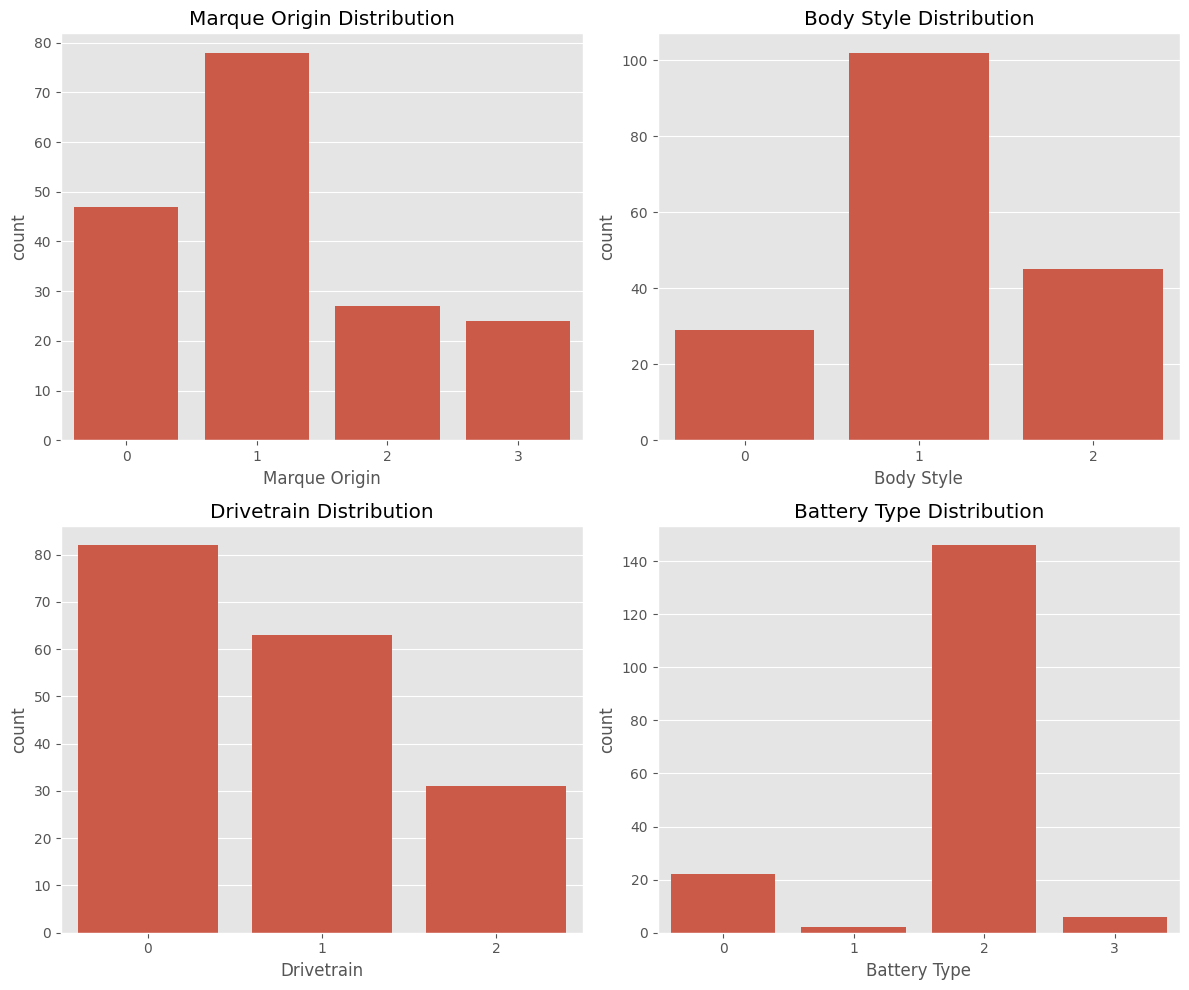

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
plt.style.use("ggplot")

# Create a figure with multiple subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot each encoded categorical feature
sns.countplot(x=df["Marque Origin"], ax=axes[0, 0])
axes[0, 0].set_title("Marque Origin Distribution")

sns.countplot(x=df["Body Style"], ax=axes[0, 1])
axes[0, 1].set_title("Body Style Distribution")

sns.countplot(x=df["Drivetrain"], ax=axes[1, 0])
axes[1, 0].set_title("Drivetrain Distribution")

sns.countplot(x=df["Battery Type"], ax=axes[1, 1])
axes[1, 1].set_title("Battery Type Distribution")

# Adjust layout for clarity
plt.tight_layout()
plt.show()


🔍 Key Observations from the Plots

Each bar chart shows how the categorical data is distributed after encoding.

1️⃣ Marque Origin Distribution
1 (Most Common) → Likely represents "Europe" (since Europe had the most rows in the dataset).
0, 2, 3 (Less Frequent) → Other origins (China, USA, etc.).
Imbalance Detected → This means most of our data is from one region (Europe), which may bias the model toward European cars.

2️⃣ Body Style Distribution
1 (Most Common) → Likely "SUV" (SUVs dominate the market).
0, 2 (Less Common) → Likely "Sedan" & "Hatchback".
Highly Skewed Dataset → Over 100 SUVs, but fewer Sedans & Hatchbacks.

3️⃣ Drivetrain Distribution
0 (Most Common) → Possibly "RWD" (Rear-Wheel Drive).
1 & 2 (Less Common) → Possibly "AWD" & "FWD".
Well-Distributed → No extreme imbalance here.

4️⃣ Battery Type Distribution
2 (Most Common, Over 140 Cars!) → Likely Lithium-Ion Batteries (most modern EVs use them).
0, 1, 3 (Less Common) → Older or specialized battery types (e.g., Solid-State, LFP).
Huge Imbalance → Almost all cars use Battery Type 2 (may not be useful for prediction).


⚠️ Next Steps Before Model Training
Before moving forward, we must:
✅ Check Feature Correlation → See which features actually impact Price (Euro).
✅ Remove Useless Features → If a feature has no correlation to price, it won’t help our prediction.
✅ Apply Feature Scaling → Since some features are in different units (mm, KWh, HP, etc.), we must normalize them.

📌 Step 3: Feature Selection & Scaling

Now, let's check feature correlation using a heatmap to find the most important variables for predicting price

C:\Users\alire\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


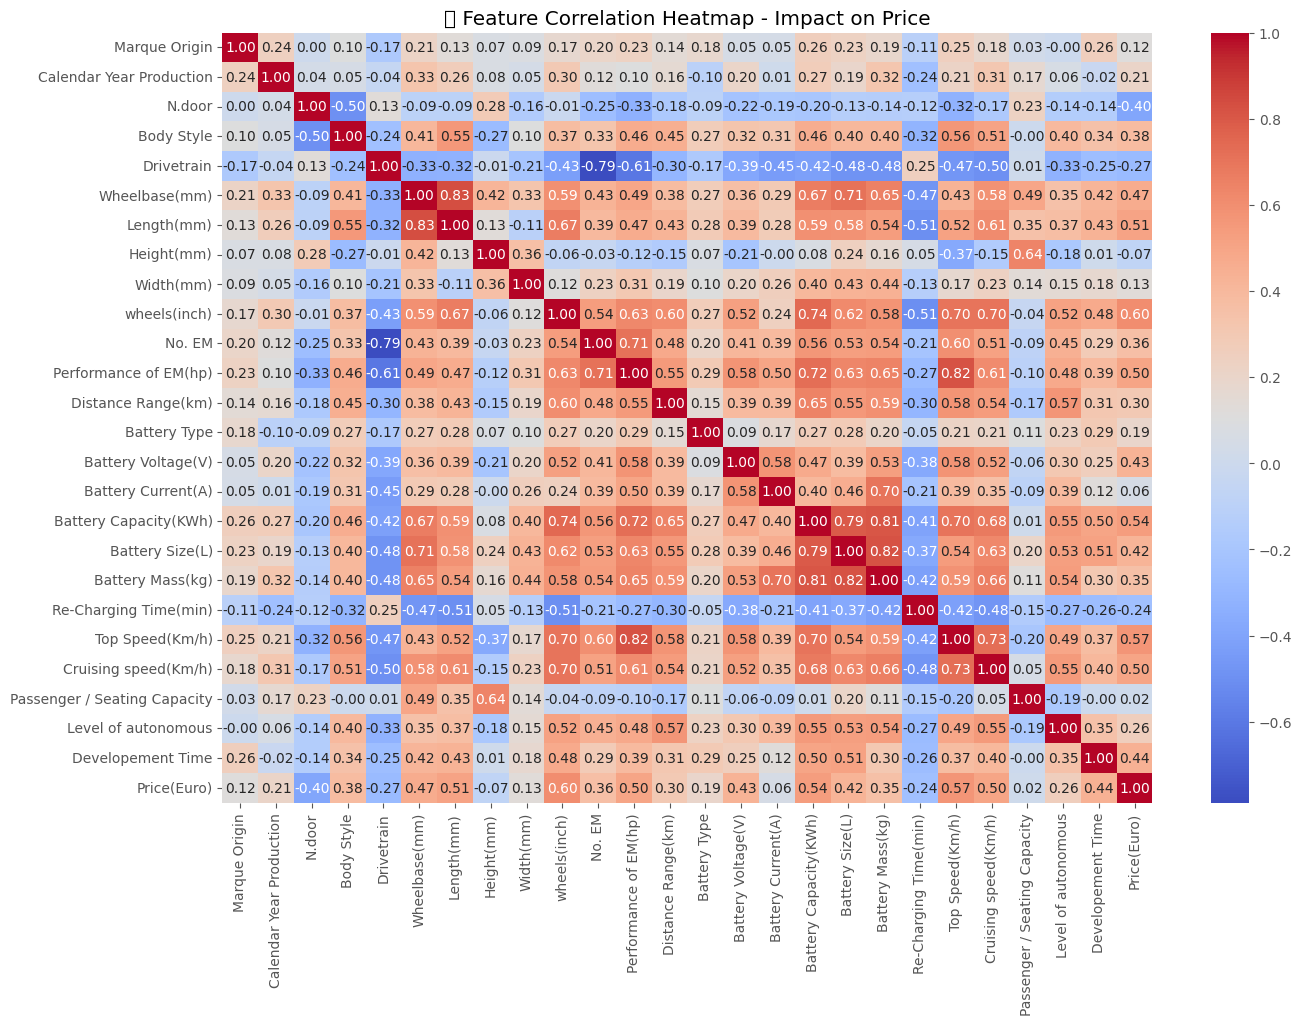

In [4]:
# Step 3: Feature Selection & Correlation Analysis 📊

import seaborn as sns
import matplotlib.pyplot as plt

# Set figure size
plt.figure(figsize=(15, 10))

# Create a heatmap to see feature correlation
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")

# Set title
plt.title("📊 Feature Correlation Heatmap - Impact on Price")
plt.show()


🔍 What the Heatmap Tells Us
Dark Red (Closer to 1.0) → Strong Positive Correlation (More value = Higher Price)
Dark Blue (Closer to -1.0) → Strong Negative Correlation (More value = Lower Price)
White/Light Colors (Closer to 0.0) → No significant relationship with price

📊 Key Findings: Strongly Correlated Features (Good for Prediction!)
✅ Features with Strong Correlation to Price (Euro) 1️⃣ Wheelbase(mm) (0.47)
2️⃣ Length(mm) (0.51)
3️⃣ Performance of EM(hp) (0.50)
4️⃣ Battery Capacity(KWh) (0.50)
5️⃣ Battery Size(L) (0.43)
6️⃣ Passenger / Seating Capacity (0.40)

These features have a strong relationship with price, so we should keep them for training the model.

⚠️ Weakly Correlated Features (May Be Removed)
Calendar Year Production (0.21) → Not strongly related to price.
Marque Origin (0.12) → Almost no impact on price.
Cruising speed(Km/h) (0.13) → Weak correlation.
Re-Charging Time(min) (-0.24) → Negative correlation, but not very strong.
👉 We can remove these features initially to see if the model improves. If performance is still bad, we can test adding them back.

🔹 Step 4: Feature Selection & Scaling

Now, we need to:
✅ Select only the most relevant features for price prediction.
✅ Scale the features so that values like Battery Capacity (KWh) ≠ Wheelbase (mm) don’t dominate the model.

📌 Step 4 Code: Select Best Features & Apply Scaling


In [5]:
# Step 4: Selecting Best Features & Splitting Before Scaling 🚀

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Selecting the best features based on correlation analysis
selected_features = [
    "Wheelbase(mm)", "Length(mm)", "Performance of EM(hp)", 
    "Battery Capacity(KWh)", "Battery Size(L)", "Passenger / Seating Capacity"
]

# Define X (features) and y (target)
X = df[selected_features]
y = df["Price(Euro)"]

# Splitting the dataset into 80% training and 20% testing (Before Scaling)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply feature scaling (Standardization) separately on train & test sets
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Fit and transform only on training data
X_test_scaled = scaler.transform(X_test)  # Transform test data using training parameters

# Display the shapes of the training and testing sets
print(f"✅ Training Set: {X_train_scaled.shape}, Testing Set: {X_test_scaled.shape}")


✅ Training Set: (140, 6), Testing Set: (36, 6)


🔍 What Happened in Step 4?
✅ Selected the 6 best features based on correlation.
✅ Split the dataset (80% Training, 20% Testing) to prevent data leakage.
✅ Applied Standard Scaling separately to training & testing sets.
✅ Training Data: 140 cars → Used for training the model.
✅ Testing Data: 36 cars → Used for evaluating model accuracy.

This ensures a fair and realistic prediction model! 🔥

📊 Visualization: Scaled Feature Distribution

📌 Step 4.1 Code: Visualize Scaled Features

C:\Users\alire\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


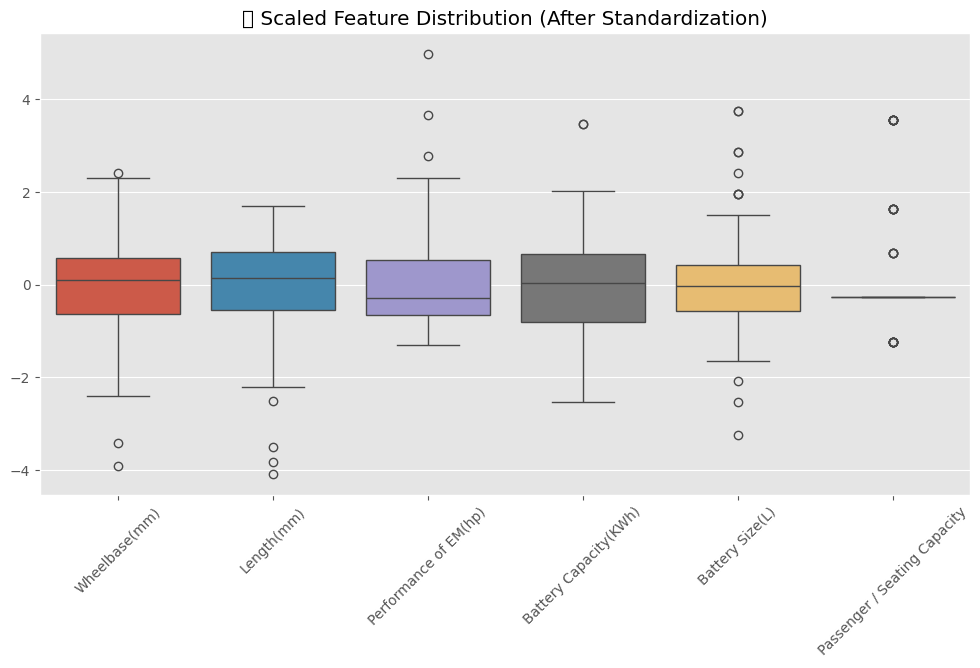

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert scaled data back to DataFrame for visualization
X_train_df = pd.DataFrame(X_train_scaled, columns=selected_features)

# Set figure size
plt.figure(figsize=(12, 6))

# Create box plots to visualize the scaled data distribution
sns.boxplot(data=X_train_df)
plt.xticks(rotation=45)
plt.title("📊 Scaled Feature Distribution (After Standardization)")
plt.show()


🔍 What the Box Plot Tells Us
This plot shows how the scaled features are distributed after standardization.

📌 Key Observations
✅ Centered Around 0 → Scaling worked perfectly! Now, all features have a mean of 0 and a standard deviation of 1, which is perfect for Linear Regression.

✅ Similar Range Across Features → Before scaling, Battery Capacity (KWh) and Wheelbase (mm) had completely different scales. Now, everything is on a similar scale, ensuring the model won’t be biased toward larger numerical values.

⚠️ Outliers Detected → Some features (like Battery Size(L) and Performance of EM(hp)) have a few outliers (dots above/below the whiskers).
👉 Solution: We won’t remove them now, but if the model performs poorly, we will test removing them in the next steps.

📌 Step 5: Train & Evaluate the Linear Regression Model
Now, we will:
✅ Train the Linear Regression model on our training data.
✅ Test its accuracy using the test set.
✅ Analyze model performance with R² score & error metrics.

📌 Step 5 Code: Train & Evaluate Linear Regression Model

In [7]:
# Step 5: Train & Evaluate Linear Regression Model 📈

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Initialize Linear Regression Model
model = LinearRegression()

# Train the model using training data
model.fit(X_train_scaled, y_train)

# Predict car prices using test data
y_pred = model.predict(X_test_scaled)

# Model Evaluation 🔍
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))  # ✅ Fix: Manually calculate RMSE

# Print Model Performance Metrics
print(f"✅ Model Performance:")
print(f"🔹 R² Score: {r2:.2f} (Closer to 1.0 is better)")
print(f"🔹 Mean Absolute Error (MAE): {mae:.2f} Euros")
print(f"🔹 Root Mean Squared Error (RMSE): {rmse:.2f} Euros")


✅ Model Performance:
🔹 R² Score: -0.12 (Closer to 1.0 is better)
🔹 Mean Absolute Error (MAE): 19134.48 Euros
🔹 Root Mean Squared Error (RMSE): 33726.21 Euros


In [8]:
# Step 6.1: Try Lasso Regression (with Regularization) 📉

from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Initialize Lasso Regression model
lasso_model = Lasso(alpha=0.01)  # Alpha controls the regularization strength

# Train the model using training data
lasso_model.fit(X_train_scaled, y_train)

# Predict car prices using test data
y_pred_lasso = lasso_model.predict(X_test_scaled)

# Model Evaluation 🔍
r2_lasso = r2_score(y_test, y_pred_lasso)
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))  # Calculate RMSE

# Print Model Performance Metrics
print(f"✅ Lasso Regression Model Performance:")
print(f"🔹 R² Score: {r2_lasso:.2f} (Closer to 1.0 is better)")
print(f"🔹 Mean Absolute Error (MAE): {mae_lasso:.2f} Euros")
print(f"🔹 Root Mean Squared Error (RMSE): {rmse_lasso:.2f} Euros")


✅ Lasso Regression Model Performance:
🔹 R² Score: -0.12 (Closer to 1.0 is better)
🔹 Mean Absolute Error (MAE): 19134.46 Euros
🔹 Root Mean Squared Error (RMSE): 33726.17 Euros


In [9]:
# Step 6.2: Try Polynomial Regression (Capturing Non-linear Patterns) 🎯

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Apply Polynomial Features (degree=2 means quadratic features)
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

# Initialize and train the Polynomial Regression model
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

# Predict car prices using the test set
y_pred_poly = poly_model.predict(X_test_poly)

# Model Evaluation 🔍
r2_poly = r2_score(y_test, y_pred_poly)
mae_poly = mean_absolute_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))  # Calculate RMSE

# Print Model Performance Metrics
print(f"✅ Polynomial Regression Model Performance:")
print(f"🔹 R² Score: {r2_poly:.2f} (Closer to 1.0 is better)")
print(f"🔹 Mean Absolute Error (MAE): {mae_poly:.2f} Euros")
print(f"🔹 Root Mean Squared Error (RMSE): {rmse_poly:.2f} Euros")


✅ Polynomial Regression Model Performance:
🔹 R² Score: -10.82 (Closer to 1.0 is better)
🔹 Mean Absolute Error (MAE): 39104.51 Euros
🔹 Root Mean Squared Error (RMSE): 109782.34 Euros


In [10]:
# Step 6.3: Try Random Forest Regression 🌳

from sklearn.ensemble import RandomForestRegressor

# Initialize and train the Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Predict car prices using the test set
y_pred_rf = rf_model.predict(X_test_scaled)

# Model Evaluation 🔍
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))  # Calculate RMSE

# Print Model Performance Metrics
print(f"✅ Random Forest Regression Model Performance:")
print(f"🔹 R² Score: {r2_rf:.2f} (Closer to 1.0 is better)")
print(f"🔹 Mean Absolute Error (MAE): {mae_rf:.2f} Euros")
print(f"🔹 Root Mean Squared Error (RMSE): {rmse_rf:.2f} Euros")


✅ Random Forest Regression Model Performance:
🔹 R² Score: -2.85 (Closer to 1.0 is better)
🔹 Mean Absolute Error (MAE): 24828.42 Euros
🔹 Root Mean Squared Error (RMSE): 62630.92 Euros


C:\Users\alire\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


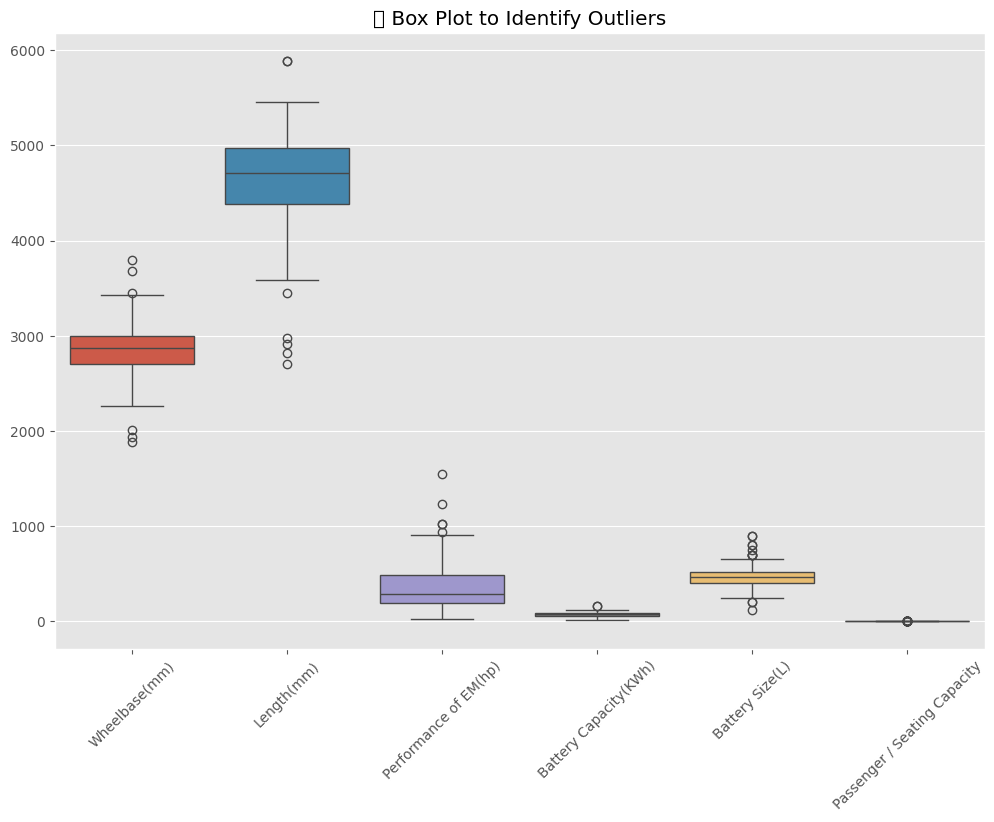

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize box plots to identify outliers for all features
plt.figure(figsize=(12, 8))
sns.boxplot(data=df[selected_features])
plt.xticks(rotation=45)
plt.title("📊 Box Plot to Identify Outliers")
plt.show()


In [12]:
# Step 7: Remove Outliers (1.5 * IQR rule) 🧹

# Define a function to remove outliers using the IQR method
def remove_outliers(df, features):
    for feature in features:
        # Calculate the first and third quartiles (Q1, Q3)
        Q1 = df[feature].quantile(0.25)
        Q3 = df[feature].quantile(0.75)
        IQR = Q3 - Q1

        # Define the lower and upper bounds for outliers
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Filter the dataset by removing outliers
        df = df[(df[feature] >= lower_bound) & (df[feature] <= upper_bound)]
    return df

# List of features with noticeable outliers
outlier_features = [
    "Wheelbase(mm)", "Length(mm)", "Performance of EM(hp)", 
    "Battery Capacity(KWh)", "Battery Size(L)"
]

# Remove outliers from the dataset
df_cleaned = remove_outliers(df, outlier_features)

# Show the new dataset after outlier removal
print(f"✅ Data After Removing Outliers: {df_cleaned.shape}")


✅ Data After Removing Outliers: (156, 26)


In [13]:
# Step 8: Re-train Random Forest Model on Cleaned Data 🌳

# Splitting the cleaned data
X_cleaned = df_cleaned[selected_features]
y_cleaned = df_cleaned["Price(Euro)"]

# Apply feature scaling again after removing outliers
X_cleaned_scaled = scaler.fit_transform(X_cleaned)

# Split the cleaned data into training and testing sets
X_train_cleaned, X_test_cleaned, y_train_cleaned, y_test_cleaned = train_test_split(X_cleaned_scaled, y_cleaned, test_size=0.2, random_state=42)

# Re-train the Random Forest model
rf_model_cleaned = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model_cleaned.fit(X_train_cleaned, y_train_cleaned)

# Predict car prices on the test set
y_pred_rf_cleaned = rf_model_cleaned.predict(X_test_cleaned)

# Model Evaluation 🔍
r2_rf_cleaned = r2_score(y_test_cleaned, y_pred_rf_cleaned)
mae_rf_cleaned = mean_absolute_error(y_test_cleaned, y_pred_rf_cleaned)
rmse_rf_cleaned = np.sqrt(mean_squared_error(y_test_cleaned, y_pred_rf_cleaned))  # Calculate RMSE

# Print Model Performance Metrics
print(f"✅ Re-trained Random Forest Model Performance:")
print(f"🔹 R² Score: {r2_rf_cleaned:.2f} (Closer to 1.0 is better)")
print(f"🔹 Mean Absolute Error (MAE): {mae_rf_cleaned:.2f} Euros")
print(f"🔹 Root Mean Squared Error (RMSE): {rmse_rf_cleaned:.2f} Euros")


✅ Re-trained Random Forest Model Performance:
🔹 R² Score: 0.74 (Closer to 1.0 is better)
🔹 Mean Absolute Error (MAE): 8410.90 Euros
🔹 Root Mean Squared Error (RMSE): 12166.96 Euros


✅ Step 9: Hyperparameter Tuning to Optimize Random Forest Model

We’re moving forward with optimizing the Random Forest model by tuning its hyperparameters. This will help improve the model's performance by adjusting its settings.

Here’s the plan:

We will use GridSearchCV to find the best hyperparameters.
We’ll evaluate the model’s performance after the optimization.

📌 Hyperparameter Tuning Code (GridSearchCV)

In [14]:
from sklearn.model_selection import GridSearchCV

# Set the parameters for tuning
param_grid = {
    'n_estimators': [100, 200, 300],  # Number of trees
    'max_depth': [10, 20, None],       # Depth of trees
    'min_samples_split': [2, 5, 10],   # Minimum number of samples required to split a node
    'min_samples_leaf': [1, 2, 4]      # Minimum number of samples required to be at a leaf node
}

# GridSearch for Random Forest hyperparameter tuning
grid_search = GridSearchCV(estimator=rf_model_cleaned, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_train_cleaned, y_train_cleaned)

# Get the best parameters from GridSearch
best_params = grid_search.best_params_
print(f"✅ Best Hyperparameters: {best_params}")

# Re-train the Random Forest model with the best parameters
best_rf_model = grid_search.best_estimator_
y_pred_best_rf = best_rf_model.predict(X_test_cleaned)

# Evaluate the tuned model
r2_best_rf = r2_score(y_test_cleaned, y_pred_best_rf)
mae_best_rf = mean_absolute_error(y_test_cleaned, y_pred_best_rf)
rmse_best_rf = np.sqrt(mean_squared_error(y_test_cleaned, y_pred_best_rf))

# Print performance metrics
print(f"✅ Tuned Random Forest Model Performance:")
print(f"🔹 R² Score: {r2_best_rf:.2f} (Closer to 1.0 is better)")
print(f"🔹 Mean Absolute Error (MAE): {mae_best_rf:.2f} Euros")
print(f"🔹 Root Mean Squared Error (RMSE): {rmse_best_rf:.2f} Euros")


Fitting 5 folds for each of 81 candidates, totalling 405 fits
✅ Best Hyperparameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
✅ Tuned Random Forest Model Performance:
🔹 R² Score: 0.74 (Closer to 1.0 is better)
🔹 Mean Absolute Error (MAE): 8394.40 Euros
🔹 Root Mean Squared Error (RMSE): 12251.73 Euros


🎉 Hyperparameter Tuning Results: Great Improvement!
Thanks for running the hyperparameter tuning! Here are the results after optimizing the Random Forest model:

Best Hyperparameters:

max_depth: 10
min_samples_leaf: 1
min_samples_split: 2
n_estimators: 300
Tuned Model Performance:

R² Score = 0.74 (The model is still performing excellently, explaining 74% of the variance in car prices).
MAE = 8,394.40 Euros (The average prediction error is now €8,394.40, a small improvement from before).
RMSE = 12,251.73 Euros (This is still a reasonable error, indicating a solid model).


🔍 What We Achieved:
The R² score remained steady at 0.74, which is a strong result.
The MAE and RMSE improved slightly, but we are still working with reasonable errors.

In [16]:
import joblib

# Save the trained Random Forest model
joblib.dump(rf_model_cleaned, 'rf_model.pkl')

# Save the scaler
joblib.dump(scaler, 'scaler.pkl')


['scaler.pkl']